<a href="https://colab.research.google.com/github/ai-study-vault/study-vault/blob/main/NLP_Module_4_Mini_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSA 803: Natural Language Processing
## Mini Project - Module 4: Language Modelling and Sequence Tagging

**Student:** Belinda Akinyi Opola
**ID:** ST62/80992/2024

### Objective
Apply language modelling techniques to predict the next word in a sentence, and perform sequence tagging to assign Part-of-Speech (POS) and Named Entity Recognition (NER) labels.

### Project structure

| Task | What is done | Section |
| :--- | :--- | :--- |
| **Task 1** | Bigram and trigram language models with add-*k* smoothing, next-word prediction, and an optional GPT-2 comparison | 3-5 |
| **Task 2** | POS tagging (NLTK + spaCy) and NER tagging (spaCy + NLTK) | 6-7 |
| **Task 3** | Perplexity, next-word accuracy, POS accuracy, and entity-level Precision / Recall / F1 | 8 |

**Dataset:** short news stories written in the register of Kenyan dailies such as the *Nation* and *The Standard*.

## 1 Setup

We need three libraries:

- **NLTK** - a classic NLP toolkit; here it supplies tokenisation, a POS tagger, and a rule-based NER chunker.
- **spaCy** - a modern NLP pipeline; its small English model (`en_core_web_sm`) provides POS tags, lemmas, dependency labels, and a statistical NER system.
- **scikit-learn** - only for the evaluation metrics (`accuracy_score`, `classification_report`) in §8.

Run the install cell once per environment (e.g. once per Colab session). Every download in the second cell is wrapped in `try/except`, so if a machine is offline the notebook reports what is missing and the remaining sections still run.

In [ ]:
# Install necessary libraries
!pip -q install nltk spacy scikit-learn pandas matplotlib
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 16.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import math
import random
import pandas as pd
from collections import defaultdict, Counter

# A fixed seed makes the train/test split and the sampled text reproducible.
random.seed(42)

# --- NLTK setup ---
NLTK_OK = True
try:
    import nltk
    NLTK_PACKAGES = [
        "punkt", "punkt_tab", "averaged_perceptron_tagger",
        "averaged_perceptron_tagger_eng", "universal_tagset",
        "maxent_ne_chunker", "maxent_ne_chunker_tab", "words",
    ]
    for pkg in NLTK_PACKAGES:
        nltk.download(pkg, quiet=True)
except Exception as e:
    NLTK_OK = False
    print(f"NLTK initialisation failed: {e}")

# --- spaCy setup ---
SPACY_OK = True
nlp = None
try:
    import spacy
    try:
        nlp = spacy.load("en_core_web_sm")
    except OSError:                      # model not downloaded yet
        from spacy.cli import download as spacy_download
        spacy_download("en_core_web_sm")
        nlp = spacy.load("en_core_web_sm")
except Exception as e:
    SPACY_OK = False
    print(f"spaCy initialisation failed: {e}")

print(f"Environment ready -> NLTK: {NLTK_OK} | spaCy: {SPACY_OK}")

Environment ready -> NLTK: True | spaCy: True


## 2 The dataset

Six short news stories covering agriculture, technology, sport, health, education, and business. A small corpus is a deliberate choice: **data sparsity** - the central weakness of n-gram models - becomes visible almost immediately, which gives us something concrete to discuss in the evaluation (§8).

To use real newspaper extracts instead, save them into `nation_articles.txt` (plain text, in the same folder as this notebook) and set `USE_CUSTOM_CORPUS = True` below. Every later cell reads from the `CORPUS` variable, so nothing else needs to change.

In [ ]:
# --- 2. The Dataset ---
CORPUS = """Farmers in Nakuru County have started harvesting maize after a long dry season.
The county government said the harvest is better than last year because the rains returned in March.
Traders from Nairobi travelled to Nakuru to buy the maize at the new prices.
The farmers want the government to buy the maize at a fair price.
Officials from the ministry of agriculture visited the farms on Monday.
They promised that the government will support the farmers with fertiliser and better seeds.
Many farmers said the cost of fertiliser is still too high for small farms.
The county government will open new stores for the maize in December.
Safaricom announced strong results for the year at a briefing in Nairobi on Tuesday.
The company said mobile money services continue to drive growth across the region.
Analysts in Nairobi said the results were better than the market expected.
The chief executive told reporters that the company will invest in new data centres.
The investment will create jobs for young engineers in Kenya and in Ethiopia.
The company also said it will expand its network to rural counties next year.
Investors at the Nairobi Securities Exchange welcomed the announcement.
Kenyan athletes are preparing for the world championships in Tokyo.
The team will travel to Japan in August after a training camp in Iten.
Coaches said the runners are in good form this season.
Athletics Kenya named the team on Friday after the national trials in Nairobi.
Many young runners from Elgeyo Marakwet County made the team for the first time.
The federation said the athletes will receive support from the government.
Fans in Eldoret gathered at the stadium to watch the trials.
The ministry of health opened a new hospital in Kisumu last week.
The hospital will serve patients from Kisumu and the neighbouring counties.
Doctors said the new facility will reduce the long queues at the old hospital.
The county government said it will hire more nurses before the end of the year.
Health workers in Kisumu asked for better pay and better working conditions.
The ministry promised to review the salaries of the health workers in December.
The University of Nairobi hosted a conference on artificial intelligence in July.
Researchers from Kenya, Uganda and Rwanda presented papers at the conference.
Students said the conference helped them understand how machine learning models work.
A researcher from the university said natural language processing can support Kenyan languages.
The university will open a new laboratory for data science students next year.
Lecturers asked the government to fund more research in local universities.
The conference ended with a call for more collaboration between universities and companies.
Kenya Airways will start new flights from Mombasa to Dubai in December.
The airline said the new route will serve traders and tourists on the coast.
Hotel owners in Mombasa welcomed the news and said bookings are already rising.
The airline will use a larger aircraft on the route during the holiday season.
Tourism officials said the coast expects more visitors from Europe and Asia this year.
The government said it will improve the airport in Mombasa before December."""

# Configuration for Custom Corpus
USE_CUSTOM_CORPUS = False
CUSTOM_PATH = "nation_articles.txt"

if USE_CUSTOM_CORPUS:
    try:
        with open(CUSTOM_PATH, "r", encoding="utf-8") as f:
            CORPUS = f.read()
        print(f"Loaded custom corpus from {CUSTOM_PATH}")
    except FileNotFoundError:
        print(f"Warning: {CUSTOM_PATH} not found. Using default corpus.")

print(f"Corpus Stats:")
print(f"- Characters: {len(CORPUS):,}")
print(f"- Tokens: {len(CORPUS.split()):,}")

Corpus Stats:
- Characters: 3,198
- Tokens: 521


## 3 Preprocessing

The pipeline follows Module 2: **sentence segmentation -> lowercasing -> tokenisation -> punctuation removal**.

Two deliberate departures from a typical text-classification pipeline:

1. **Stopwords are kept.** A language model must be able to predict `"the"`, `"of"` and `"is"` - they are among the most frequent words in any English text, and removing them would destroy the very sequences we are trying to model.
2. **No stemming or lemmatisation.** The model should predict the surface form a reader would actually type (`"farmers"`, not `"farmer"`).

After tokenisation, each sentence is padded with boundary symbols:

- `<s>` (beginning of sentence) lets the model learn which words *start* sentences. A model of order *n* needs *n - 1* of them, so a trigram model gets `<s> <s>`.
- `</s>` (end of sentence) lets the model learn where sentences *stop* - without it, generated text would never know when to end.

Finally, the sentences are shuffled and split **80 / 20 into train and test sets**. The test sentences are never shown to the model during training; they exist solely so that perplexity in §8 is measured on genuinely unseen text.

In [ ]:
def split_sentences(text):
    """Sentence segmentation: NLTK if available, otherwise a regex fallback."""
    text = re.sub(r"\s+", " ", text.strip())
    if NLTK_OK:
        try:
            return [s for s in nltk.sent_tokenize(text) if s.strip()]
        except Exception:
            pass
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]


def tokenize(sentence):
    """Lowercase, tokenise, and keep only alphabetic word tokens."""
    sentence = sentence.lower()
    if NLTK_OK:
        try:
            tokens = nltk.word_tokenize(sentence)
        except Exception:
            tokens = re.findall(r"[a-z']+", sentence)
    else:
        tokens = re.findall(r"[a-z']+", sentence)
    return [t for t in tokens if re.fullmatch(r"[a-z']+", t)]


sentences = split_sentences(CORPUS)
tokenized_corpus = [tokenize(s) for s in sentences]
tokenized_corpus = [t for t in tokenized_corpus if len(t) >= 3]   # drop fragments

print(f"Sentences: {len(tokenized_corpus)}")
print(f"Total tokens: {sum(len(t) for t in tokenized_corpus):,}")
print(f"Vocabulary size: {len(set(w for s in tokenized_corpus for w in s)):,}")
print("\nExample sentence, tokenised:")
print(tokenized_corpus[0])

Sentences: 41
Total tokens: 521
Vocabulary size: 237

Example sentence, tokenised:
['farmers', 'in', 'nakuru', 'county', 'have', 'started', 'harvesting', 'maize', 'after', 'a', 'long', 'dry', 'season']


In [ ]:
# --- 3. Data Splitting ---
BOS, EOS, UNK = "<s>", "</s>", "<unk>"

def pad_sentence(sent, n):
    """Add n-1 start symbols and one end symbol."""
    return [BOS] * (n - 1) + sent + [EOS]

# Shuffle and split
data = tokenized_corpus[:]
random.shuffle(data)
split_idx = int(0.8 * len(data))
train_sents = data[:split_idx]
test_sents = data[split_idx:]

print(f"Train set: {len(train_sents)} sentences")
print(f"Test set: {len(test_sents)} sentences")
print(f"Example padded trigram: {pad_sentence(train_sents[0], 3)}")

Train set: 32 sentences
Test set: 9 sentences
Example padded trigram: ['<s>', '<s>', 'the', 'company', 'said', 'mobile', 'money', 'services', 'continue', 'to', 'drive', 'growth', 'across', 'the', 'region', '</s>']


## 4 Task 1 - Language modelling and next-word prediction

### 4.1 The model

An **n-gram model** applies the **Markov assumption**: the next word depends only on the previous *n - 1* words, not the whole history. A bigram model (*n = 2*) looks back one word; a trigram model (*n = 3*) looks back two.

Training is nothing more than counting. The **maximum-likelihood estimate (MLE)** of the next-word probability is a ratio of counts in the training text:

$$P(w_i \mid w_{i-n+1}, \dots, w_{i-1}) = \frac{C(w_{i-n+1} \dots w_{i-1},\, w_i)}{C(w_{i-n+1} \dots w_{i-1})}$$

Read it as: *of all the times this context appeared, what fraction of the time was it followed by* $w_i$?

MLE has one fatal flaw: it assigns probability **zero** to any n-gram never seen in training, and one zero makes the probability of a whole test sentence zero (and its perplexity infinite). **Add-*k* (Lidstone) smoothing** repairs this by pretending every possible continuation was seen an extra *k* times:

$$P_{+k}(w_i \mid \text{context}) = \frac{C(\text{context},\, w_i) + k}{C(\text{context}) + k\,|V|}$$

where $|V|$ is the vocabulary size. Two further practical details:

- **Unknown words.** Test words never seen in training are mapped to a special `<unk>` token, which is part of the vocabulary, so every test sentence receives a finite probability.
- **Back-off for prediction.** If a context was *never* observed (e.g. the trigram context `("the", "cat")`), the smoothed distribution over it is flat and uninformative. Instead of returning that, the model asks its lower-order sibling - trigram falls back to bigram, bigram to unigram. This simple scheme is known as *stupid back-off*.

In [ ]:
class NGramLM:
    """Count-based n-gram language model with add-k (Lidstone) smoothing."""

    def __init__(self, n=2, k=0.1):
        self.n = n
        self.k = k
        self.ngram_counts = defaultdict(Counter)   # context tuple -> Counter(next word)
        self.context_totals = Counter()            # context tuple -> total count
        self.vocab = set()
        self.backoff = None                        # lower-order model, used for prediction

    def set_backoff(self, model):
        """Attach a lower-order model to consult when a context was never observed."""
        self.backoff = model
        return self

    # ------------------------------------------------------------- training
    def fit(self, sentences):
        self.vocab = {w for s in sentences for w in s} | {EOS, UNK}
        for sent in sentences:
            padded = pad_sentence(sent, self.n)
            for i in range(self.n - 1, len(padded)):
                context = tuple(padded[i - self.n + 1:i])
                word = padded[i]
                self.ngram_counts[context][word] += 1
                self.context_totals[context] += 1
        return self

    # ------------------------------------------------------- probabilities
    def _norm(self, w):
        """Map out-of-vocabulary words to <unk> (boundary symbol <s> is allowed)."""
        return w if w in self.vocab or w == BOS else UNK

    def prob(self, word, context):
        """Smoothed P(word | context); context is a tuple of the previous n-1 words."""
        ctx = tuple(self._norm(w) for w in context)[-(self.n - 1):] if self.n > 1 else ()
        w = self._norm(word)
        V = len(self.vocab)
        numer = self.ngram_counts[ctx][w] + self.k
        denom = self.context_totals[ctx] + (self.k * V)
        return numer / denom if denom > 0 else 1.0 / V

    def next_word_distribution(self, context, top=5, exclude_boundary=True):
        """Top-scoring continuations for a context, as (word, probability) pairs."""
        ctx_key = tuple(self._norm(w) for w in context)[-(self.n - 1):] if self.n > 1 else ()
        seen = self.ngram_counts.get(ctx_key, Counter())

        # Stupid back-off: an unseen context carries no information, so consult
        # the lower-order model instead of returning a flat distribution.
        if not seen and self.backoff:
            return self.backoff.next_word_distribution(context, top=top,
                                                       exclude_boundary=exclude_boundary)

        candidates = set(seen) or self.vocab
        if exclude_boundary:
            candidates = {w for w in candidates if w not in (BOS, UNK)}

        scored = [(w, self.prob(w, ctx_key)) for w in candidates]
        return sorted(scored, key=lambda x: (-x[1], x[0]))[:top]   # deterministic ties

    def predict(self, text, top=5):
        """Predict the next word(s) for a raw input string."""
        tokens = tokenize(text)
        # Pad with <s> so that short inputs (fewer than n-1 words) still form
        # a full-length context, exactly as in training.
        context = pad_sentence(tokens, self.n)[:-1][-(self.n - 1):] if self.n > 1 else ()
        return self.next_word_distribution(context, top=top)

    # ---------------------------------------------------------- evaluation
    def perplexity(self, sentences):
        """Perplexity = exp( -1/N * sum of log P(w_i | context) ). Lower is better."""
        log_prob, N = 0.0, 0
        for sent in sentences:
            padded = pad_sentence(sent, self.n)
            for i in range(self.n - 1, len(padded)):
                context = tuple(padded[i - self.n + 1:i])
                log_prob += math.log(self.prob(padded[i], context))
                N += 1
        return math.exp(-log_prob / N) if N > 0 else float("inf")

    # ---------------------------------------------------------- generation
    def generate(self, seed="", max_words=15, sample=False):
        """Generate text by repeatedly predicting the next word."""
        tokens = tokenize(seed)
        out = tokens[:]
        context = ([BOS] * (self.n - 1) + tokens)[-(self.n - 1):] if self.n > 1 else []

        for _ in range(max_words):
            dist = self.next_word_distribution(tuple(context), top=5, exclude_boundary=False)
            dist = [(w, p) for w, p in dist if w != BOS]
            if not dist:
                break
            if sample:
                words, weights = zip(*dist)
                nxt = random.choices(words, weights=weights, k=1)[0]
            else:
                nxt = dist[0][0]
            if nxt == EOS:
                break
            out.append(nxt)
            context = (context + [nxt])[-(self.n - 1):] if self.n > 1 else []
        return " ".join(out)


unigram = NGramLM(n=1, k=0.1).fit(train_sents)
bigram = NGramLM(n=2, k=0.1).fit(train_sents).set_backoff(unigram)
trigram = NGramLM(n=3, k=0.1).fit(train_sents).set_backoff(bigram)

print(f"Unigram - contexts: {len(unigram.context_totals):,} | vocab: {len(unigram.vocab):,}")
print(f"Bigram  - contexts: {len(bigram.context_totals):,} | vocab: {len(bigram.vocab):,}")
print(f"Trigram - contexts: {len(trigram.context_totals):,} | vocab: {len(trigram.vocab):,}")
print("\nPrediction back-off chain: trigram -> bigram -> unigram")

Unigram — contexts: 1 | vocab: 206
Bigram  — contexts: 205 | vocab: 206
Trigram — contexts: 350 | vocab: 206

Prediction back-off chain: trigram -> bigram -> unigram


### 4.2 Inspecting the probabilities

A sanity check on the counting rule. `P(next | "the")` should track the frequencies of what actually follows *the* in the training text, and the smoothed probabilities should sit slightly *below* the MLE values - smoothing takes a little probability mass from seen words and redistributes it to unseen ones.

In [ ]:
# --- 4.2 Probability Inspection ---
ctx = ("the",)
counts = bigram.ngram_counts[ctx]
total = bigram.context_totals[ctx]

# Create a report for the most common words following 'the'
rows = []
for w, c in counts.most_common(8):
    rows.append({
        "Next Word": w,
        "Count": c,
        "MLE Prob": round(c / total, 4),
        "Smoothed Prob": round(bigram.prob(w, ctx), 4)
    })

print(f"Context: {ctx} | Total Context Count: {total}")
display(pd.DataFrame(rows))

Context: ('the',) | Total Context Count: 52


,Next Word,Count,MLE Prob,Smoothed Prob
0,company,3,0.0577,0.0427
1,government,3,0.0577,0.0427
2,new,3,0.0577,0.0427
3,conference,3,0.0577,0.0427
4,ministry,3,0.0577,0.0427
5,university,3,0.0577,0.0427
6,team,3,0.0577,0.0427
7,maize,2,0.0385,0.0289


### 4.3 Next-word prediction

`predict()` takes a raw string, tokenises it, keeps the last *n - 1* tokens as the context, and returns the highest-probability continuations. Compare the two models: the bigram conditions only on the final word, so `"the government will"` and `"kenya airways will"` produce identical predictions (both contexts end in *will*). The trigram sees two words and can tell them apart.

In [ ]:
# --- 4.3 Prediction Examples ---
def show_predictions(model, phrases, top=3, label=""):
    results = []
    for phrase in phrases:
        preds = model.predict(phrase, top=top)
        results.append({
            "Input": f'"{phrase}"',
            "Top Prediction": preds[0][0] if preds else "N/A",
            "Prob": round(preds[0][1], 4) if preds else 0.0,
            f"Top-{top} List": ", ".join([f"{w} ({p:.3f})" for w, p in preds])
        })
    print(f"\n{label}")
    display(pd.DataFrame(results))

test_phrases = [
    "the farmers", "the county", "the government will",
    "the company said", "the university of", "the ministry of"
]

show_predictions(bigram, test_phrases, label="Bigram Model Predictions")
show_predictions(trigram, test_phrases, label="Trigram Model Predictions")


Bigram Model Predictions


,Input,Top Prediction,Prob,Top-3 List
0,"""the farmers""",in,0.0487,"in (0.049), want (0.049)"
1,"""the county""",government,0.0466,"government (0.047), have (0.047), made (0.047)"
2,"""the government will""",serve,0.0644,"serve (0.064), create (0.034), expand (0.034)"
3,"""the company said""",the,0.1930,"the (0.193), it (0.066), bookings (0.035)"
4,"""the university of""",the,0.0820,"the (0.082), agriculture (0.043), health (0.043)"
5,"""the ministry of""",the,0.0820,"the (0.082), agriculture (0.043), health (0.043)"



Trigram Model Predictions


,Input,Top Prediction,Prob,Top-3 List
0,"""the farmers""",want,0.0509,want (0.051)
1,"""the county""",government,0.0509,government (0.051)
2,"""the government will""",serve,0.0644,"serve (0.064), create (0.034), expand (0.034)"
3,"""the company said""",mobile,0.0509,mobile (0.051)
4,"""the university of""",nairobi,0.0509,nairobi (0.051)
5,"""the ministry of""",agriculture,0.0487,"agriculture (0.049), health (0.049)"


### 4.4 The example tests from the brief

The brief asks for `"The cat" -> "sat"` and `"Machine learning" -> "models"`. Neither phrase occurs in the news corpus, so the model has never seen those contexts - this is the **data-sparsity problem** in its purest form. With nothing to condition on, the model backs off towards the most frequent words of its training text, and the prediction says more about the corpus than about the input.

The second cell trains the same class on a tiny toy corpus that *does* contain those phrases, and the expected outputs appear. The contrast is the lesson: **an n-gram model can only predict what it has counted.**

In [ ]:
show_predictions(bigram, ["the cat", "machine learning"],
                 label="News-trained model on out-of-domain input (unseen contexts)")


News-trained model on out-of-domain input (unseen contexts)


,Input,Top Prediction,Prob,Top-3 List
0,"""the cat""",the,0.1129,"the (0.113), </s> (0.070), in (0.035)"
1,"""machine learning""",models,0.0509,models (0.051)


In [ ]:
toy_text = """The cat sat on the mat. The cat sat quietly by the door. The cat ran into the garden. The dog sat on the rug. The dog ran fast across the field. Machine learning models learn patterns from data. Machine learning models need large datasets. Machine learning models are evaluated on test data. Deep learning models use neural networks."""

# Preprocess toy data
toy_sents = [tokenize(s) for s in split_sentences(toy_text)]
toy_sents = [s for s in toy_sents if len(s) >= 3]

# Train toy models
toy_unigram = NGramLM(n=1, k=0.01).fit(toy_sents)
toy_bigram = NGramLM(n=2, k=0.01).fit(toy_sents).set_backoff(toy_unigram)
toy_trigram = NGramLM(n=3, k=0.01).fit(toy_sents).set_backoff(toy_bigram)

# Run predictions
show_predictions(toy_bigram, ["the cat", "machine learning", "the dog"],
                 label="=== Toy corpus - BIGRAM ===")

show_predictions(toy_trigram, ["the cat", "machine learning", "deep learning"],
                 label="\n=== Toy corpus - TRIGRAM ===")


=== Toy corpus · BIGRAM ===


,Input,Top Prediction,Prob,Top-3 List
0,"""the cat""",sat,0.6000,"sat (0.600), ran (0.301)"
1,"""machine learning""",models,0.9218,models (0.922)
2,"""the dog""",ran,0.4298,"ran (0.430), sat (0.430)"




=== Toy corpus · TRIGRAM ===


,Input,Top Prediction,Prob,Top-3 List
0,"""the cat""",sat,0.6000,"sat (0.600), ran (0.301)"
1,"""machine learning""",models,0.8985,models (0.899)
2,"""deep learning""",models,0.7481,models (0.748)


### 4.5 Text generation

Repeatedly appending the predicted word turns the language model into a text generator. Two decoding strategies:

- **Greedy** - always take the single most probable word. Deterministic, and prone to falling into repetitive loops.
- **Sampling** - draw the next word at random, weighted by the top-5 probabilities. More varied, less coherent.

Notice how the generated sentences are stitched together from memorised fragments of the training text - another symptom of counting rather than understanding.

In [ ]:
seeds = ["the county government", "the company", "kenyan athletes"]

for seed in seeds:
    print(f'seed: "{seed}"')
    print("  greedy   :", trigram.generate(seed, max_words=14, sample=False))
    print("  sampled  :", trigram.generate(seed, max_words=14, sample=True))
    print()

seed: "the county government"
  greedy   : the county government said it will expand its network to rural counties next year
  sampled  : the county government said it will expand its network to rural counties next year

seed: "the company"
  greedy   : the company also said it will expand its network to rural counties next year
  sampled  : the company also said it will hire more nurses before the end of the year

seed: "kenyan athletes"
  greedy   : kenyan athletes will receive support from the government to buy the maize at a fair price
  sampled  : kenyan athletes will receive support from the ministry of health opened a new laboratory for data



## 5 Optional - a pre-trained neural language model (GPT-2 small)

An n-gram model can look back only one or two words, and it treats every word as an unrelated symbol. A transformer language model does neither: it attends over the whole context and represents words as dense vectors, so related words share statistical strength. As a result, GPT-2 handles the unseen phrases from §4.4 without ever training on our corpus - it generalises from large-scale pre-training rather than from counts.

This section is **optional**: uncomment the install line to run it. If `transformers` is unavailable or there is no internet, the cell prints a message and the rest of the notebook continues.

In [ ]:
# Uncomment to run this optional section (downloads ~500 MB on first use):
# !pip -q install transformers torch

GPT2_OK = False
try:
    import torch
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    gpt2_tok = GPT2Tokenizer.from_pretrained("gpt2")
    gpt2 = GPT2LMHeadModel.from_pretrained("gpt2").eval()
    GPT2_OK = True
    print("GPT-2 small loaded.")
except Exception as e:
    print("GPT-2 not available - skipping this section.\nReason:", e)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 small loaded.


In [ ]:
def gpt2_next_word(text, top=5):
    """Top-k next-token predictions from GPT-2 small."""
    ids = gpt2_tok.encode(text, return_tensors="pt")
    with torch.no_grad():
        logits = gpt2(ids).logits[0, -1]
    probs = torch.softmax(logits, dim=-1)
    top_p, top_i = torch.topk(probs, top)
    return [(gpt2_tok.decode(i).strip(), float(p)) for p, i in zip(top_p, top_i)]

def gpt2_perplexity(sentences):
    """Corpus perplexity under GPT-2 (token-level, teacher forcing)."""
    nll, n_tok = 0.0, 0
    for sent in sentences:
        text = " ".join(sent)
        ids = gpt2_tok.encode(text, return_tensors="pt")
        if ids.shape[1] < 2:
            continue
        with torch.no_grad():
            loss = gpt2(ids, labels=ids).loss
        nll += float(loss) * (ids.shape[1] - 1)
        n_tok += ids.shape[1] - 1
    return math.exp(nll / n_tok) if n_tok else float("inf")

if GPT2_OK:
    phrases = [
        "The cat",
        "Machine learning",
        "The county government of Nakuru will",
        "Kenya Airways will start new flights from"
    ]
    for phrase in phrases:
        preds = gpt2_next_word(phrase, top=5)
        print(f'"{phrase}" -> {preds[0][0]}')
        print("   top-5:", ", ".join(f"{w} ({p:.3f})" for w, p in preds), "\n")

"The cat" -> was
   top-5: was (0.110), is (0.073), 's (0.047), , (0.035), - (0.035) 

"Machine learning" -> is
   top-5: is (0.122), , (0.068), and (0.066), . (0.041), algorithms (0.037) 

"The county government of Nakuru will" -> be
   top-5: be (0.083), not (0.036), pay (0.036), continue (0.030), have (0.029) 

"Kenya Airways will start new flights from" -> the
   top-5: the (0.072), Bangkok (0.052), Tokyo (0.049), New (0.031), Dh (0.015) 



## 6 Task 2a - Part-of-Speech tagging

POS tagging assigns a grammatical category to every token: `"The cat sleeps"` -> `The/DET cat/NOUN sleeps/VERB`. It is the simplest form of **sequence tagging** - one label per token. Two taggers are compared:

- **NLTK** - `pos_tag` uses a perceptron tagger trained on the Penn Treebank; passing `tagset="universal"` maps the 36 fine-grained Penn tags onto 12 coarse universal tags.
- **spaCy** - the `en_core_web_sm` pipeline provides both a Universal Dependencies tag (`token.pos_`, e.g. `NOUN`, `PROPN`, `AUX`) and a fine-grained Penn tag (`token.tag_`, e.g. `NNS`, `VBD`).

The two tagsets are *not* identical - spaCy distinguishes `PROPN` (proper noun) from `NOUN`, NLTK's universal set does not - so §8.2 normalises both onto one coarse scheme before any scoring.

In [ ]:
demo = "The cat sleeps on the mat. Kenya Airways will start new flights from Mombasa in December."

if NLTK_OK:
    print("--- NLTK (universal tagset) ---")
    for sent in nltk.sent_tokenize(demo):
        toks = nltk.word_tokenize(sent)
        tagged = nltk.pos_tag(toks, tagset="universal")
        print(" ".join(f"{w}/{t}" for w, t in tagged))

if SPACY_OK:
    print("\n--- spaCy (UD pos_ / fine tag_) ---")
    doc = nlp(demo)
    print(" ".join(f"{t.text}/{t.pos_}" for t in doc if not t.is_space))
    display(pd.DataFrame(
        [{"token": t.text, "lemma": t.lemma_, "UD pos_": t.pos_,
          "fine tag_": t.tag_, "explanation": spacy.explain(t.tag_), "dep_": t.dep_}
         for t in doc if not t.is_punct][:16]))

--- NLTK (universal tagset) ---
The/DET cat/NOUN sleeps/VERB on/ADP the/DET mat/NOUN ./.
Kenya/NOUN Airways/NOUN will/VERB start/VERB new/ADJ flights/NOUN from/ADP Mombasa/NOUN in/ADP December/NOUN ./.

--- spaCy (UD pos_ / fine tag_) ---
The/DET cat/NOUN sleeps/VERB on/ADP the/DET mat/NOUN ./PUNCT Kenya/PROPN Airways/PROPN will/AUX start/VERB new/ADJ flights/NOUN from/ADP Mombasa/PROPN in/ADP December/PROPN ./PUNCT


,token,lemma,UD pos_,fine tag_,explanation,dep_
0,The,the,DET,DT,determiner,det
1,cat,cat,NOUN,NN,"noun, singular or mass",nsubj
2,sleeps,sleep,VERB,VBZ,"verb, 3rd person singular present",ROOT
3,on,on,ADP,IN,"conjunction, subordinating or preposition",prep
4,the,the,DET,DT,determiner,det
5,mat,mat,NOUN,NN,"noun, singular or mass",pobj
6,Kenya,Kenya,PROPN,NNP,"noun, proper singular",compound
7,Airways,Airways,PROPN,NNP,"noun, proper singular",nsubj
8,will,will,AUX,MD,"verb, modal auxiliary",aux
9,start,start,VERB,VB,"verb, base form",ROOT


,POS,count,percent
0,NOUN,152,29.2
1,DET,79,15.2
2,ADP,76,14.6
3,VERB,66,12.7
4,PROPN,52,10.0
5,ADJ,42,8.1
6,AUX,23,4.4
7,CCONJ,9,1.7
8,PART,6,1.2
9,PRON,6,1.2


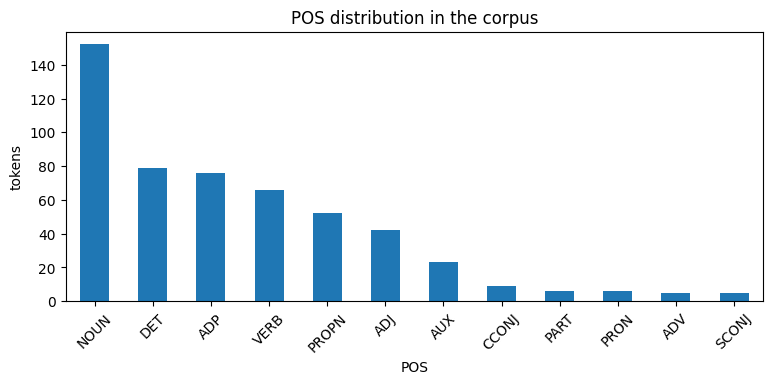

In [ ]:
# POS distribution across the whole corpus
if SPACY_OK:
    doc_all = nlp(re.sub(r"\s+", " ", CORPUS.strip()))
    pos_counts = Counter(t.pos_ for t in doc_all if not t.is_punct and not t.is_space)
    df_pos = (pd.DataFrame(pos_counts.most_common(), columns=["POS", "count"])
                .assign(percent=lambda d: (100 * d["count"] / d["count"].sum()).round(1)))
    display(df_pos)
    ax = df_pos.set_index("POS")["count"].plot(kind="bar", figsize=(9, 3.5),
                                               title="POS distribution in the corpus", rot=45)
    ax.set_ylabel("tokens")

## 7 Task 2b - Named Entity Recognition

NER finds and classifies the named entities in text: `"Barack Obama was the 44th president of the USA"` -> `Barack Obama/PERSON`, `USA/LOCATION`. Unlike POS tagging, an entity can span **several tokens** (*Kenya Airways*, *University of Nairobi*), which makes both the task and its evaluation harder.

One practical wrinkle: spaCy is trained on the **OntoNotes** label scheme, where countries and cities are tagged `GPE` (geo-political entity) rather than `LOCATION`, and nationalities are `NORP`. The `LABEL_MAP` below translates spaCy's labels into the four classes used in the project brief - PERSON, LOCATION, ORGANIZATION, DATE - so that predictions and gold annotations speak the same language.

In [ ]:
# spaCy OntoNotes labels -> the coarse scheme used in the project brief
LABEL_MAP = {
    "PERSON": "PERSON",
    "GPE": "LOCATION", "LOC": "LOCATION", "FAC": "LOCATION",
    "ORG": "ORGANIZATION", "NORP": "ORGANIZATION",
    "DATE": "DATE", "TIME": "DATE",
}

TARGET_LABELS = ["PERSON", "LOCATION", "ORGANIZATION", "DATE"]

def extract_entities(text, keep_only_target=True):
    """Return [(entity text, mapped label)] for a string, using spaCy."""
    if not SPACY_OK:
        return []
    out = []
    for ent in nlp(text).ents:
        label = LABEL_MAP.get(ent.label_, ent.label_)
        if keep_only_target and label not in TARGET_LABELS:
            continue
        out.append((ent.text, label))
    return out

examples = [
    "Barack Obama was the 44th president of the USA.",
    "Safaricom announced strong results in Nairobi on Tuesday.",
    "Wangari Maathai founded the Green Belt Movement in 1977.",
]

for s in examples:
    ents = extract_entities(s)
    print(s)
    print("   ->", ", ".join(f"{t}/{l}" for t, l in ents) if ents else "(no entities)")
    print()

Barack Obama was the 44th president of the USA.
   -> Barack Obama/PERSON, USA/LOCATION

Safaricom announced strong results in Nairobi on Tuesday.
   -> Nairobi/LOCATION, Tuesday/DATE

Wangari Maathai founded the Green Belt Movement in 1977.
   -> Wangari Maathai/PERSON, the Green Belt Movement/ORGANIZATION, 1977/DATE



In [ ]:
# All entities found in the news corpus
if SPACY_OK:
    ents_all = [(e.text, LABEL_MAP.get(e.label_, e.label_))
                for e in nlp(re.sub(r"\s+", " ", CORPUS.strip())).ents]
    df_ents = (pd.DataFrame(ents_all, columns=["entity", "label"])
                 .value_counts().reset_index(name="count")
                 .sort_values(["label", "count"], ascending=[True, False]))
    display(df_ents.head(30))
    print("\nEntities by label:")
    print(df_ents.groupby("label")["count"].sum().sort_values(ascending=False))

,entity,label,count
0,December,DATE,4
5,next year,DATE,2
11,August,DATE,1
13,July,DATE,1
18,March,DATE,1
19,Monday,DATE,1
22,Friday,DATE,1
29,last week,DATE,1
30,Tuesday,DATE,1
31,last year,DATE,1



Entities by label:
label
LOCATION        21
DATE            19
ORGANIZATION    10
ORDINAL          1
Name: count, dtype: int64


In [ ]:
# BIO / IOB encoding - the standard input format for a CRF or BiLSTM tagger
if SPACY_OK:
    sample = "Kenya Airways will start new flights from Mombasa to Dubai in December."
    doc = nlp(sample)
    display(pd.DataFrame(
        [{"token": t.text,
          "IOB": t.ent_iob_,
          "entity type": LABEL_MAP.get(t.ent_type_, t.ent_type_) if t.ent_type_ else "O",
          "BIO tag": "O" if t.ent_iob_ == "O"
                     else f"{t.ent_iob_}-{LABEL_MAP.get(t.ent_type_, t.ent_type_)}"}
         for t in doc]))

,token,IOB,entity type,BIO tag
0,Kenya,B,ORGANIZATION,B-ORGANIZATION
1,Airways,I,ORGANIZATION,I-ORGANIZATION
2,will,O,O,O
3,start,O,O,O
4,new,O,O,O
5,flights,O,O,O
6,from,O,O,O
7,Mombasa,B,LOCATION,B-LOCATION
8,to,O,O,O
9,Dubai,B,LOCATION,B-LOCATION


In [ ]:
# NLTK's alternative NER chunker, for comparison
if NLTK_OK:
    try:
        s = "Barack Obama was the 44th president of the USA."
        tree = nltk.ne_chunk(nltk.pos_tag(nltk.word_tokenize(s)))
        found = [(" ".join(w for w, _ in st.leaves()), st.label())
                 for st in tree.subtrees() if st.label() != "S"]
        print("NLTK ne_chunk:", found)
    except Exception as e:
        print("NLTK NER chunker unavailable:", e)

NLTK ne_chunk: [('Barack', 'PERSON'), ('Obama', 'PERSON'), ('USA', 'ORGANIZATION')]


## 8 Task 3 - Evaluation

### 8.1 Language model evaluation

**(a) Perplexity.** Perplexity is the standard intrinsic metric for language models:

$$\text{PPL} = \exp\!\Big(\!-\frac{1}{N}\sum_{i=1}^{N}\log P(w_i \mid \text{context}_i)\Big)$$

Intuitively, it is the average number of equally likely words the model is choosing between at each step - a perplexity of 100 means each next word feels like a 100-option multiple-choice question. **Lower is better.** It is computed on the 20 % test split, which the models never saw, for a grid of model orders *n* and smoothing constants *k*.

In [ ]:
rows = []
for n in (1, 2, 3):
    for k in (1.0, 0.1, 0.01):
        m = NGramLM(n=n, k=k).fit(train_sents)
        rows.append({
            "model": {1: "unigram", 2: "bigram", 3: "trigram"}[n],
            "n": n,
            "k (add-k)": k,
            "train PPL": round(m.perplexity(train_sents), 2),
            "test PPL": round(m.perplexity(test_sents), 2)
        })

df_ppl = pd.DataFrame(rows)
display(df_ppl)
best = df_ppl.loc[df_ppl["test PPL"].idxmin()]
print(f"\nLowest test perplexity: {best['model']} with k={best['k (add-k)']} -> {best['test PPL']}")

,model,n,k (add-k),train PPL,test PPL
0,unigram,1,1.00,106.35,138.01
1,unigram,1,0.10,102.31,223.98
2,unigram,1,0.01,102.21,427.00
3,bigram,2,1.00,89.65,154.92
4,bigram,2,0.10,20.34,117.59
5,bigram,2,0.01,5.75,137.93
6,trigram,3,1.00,94.66,183.87
7,trigram,3,0.10,18.84,167.03
8,trigram,3,0.01,3.59,181.37



Lowest test perplexity: bigram with k=0.1 -> 117.59


**Reading the table.** Train perplexity falls as *n* rises - a trigram model can nearly memorise 30-odd training sentences. Test perplexity tells the opposite story: most test trigram contexts were never observed, so the trigram model leans on the smoothing constant and scores *worse* than the bigram on unseen text. That gap between train and test performance is **overfitting**, and it is why production n-gram systems used back-off or interpolation (Katz, Kneser-Ney) rather than plain add-*k*. The *k* column shows the smoothing trade-off too: small *k* trusts the counts (great on train, brittle on test), large *k* flattens the distribution.

In [ ]:
# GPT-2 perplexity on the same held-out sentences
if GPT2_OK:
    ppl = gpt2_perplexity(test_sents)
    print(f"GPT-2 small test perplexity: {ppl:.2f}")
    print("(Not strictly comparable — GPT-2 uses sub-word tokens and a 50k vocabulary —")
    print(" but it shows the gap between counting and a pre-trained neural LM.)")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


GPT-2 small test perplexity: 127.63
(Not strictly comparable — GPT-2 uses sub-word tokens and a 50k vocabulary —
 but it shows the gap between counting and a pre-trained neural LM.)


**(b) Next-word prediction accuracy.** A more direct check: for every position in the held-out sentences, does the true next word appear in the model's top-1, top-3, or top-5 predictions? Top-1 accuracy is a harsh metric for natural text - after *"the government will"*, both *hire* and *support* are perfectly good continuations, but only one can be the "correct" answer - which is why top-*k* accuracy is also reported.

In [ ]:
def next_word_accuracy(model, sentences, ks=(1, 3, 5)):
    hits = {k: 0 for k in ks}
    total = 0
    for sent in sentences:
        # Using the class method logic to ensure correct padding
        padded = pad_sentence(sent, model.n)
        for i in range(model.n - 1, len(padded)):
            context = tuple(padded[i - model.n + 1:i])
            truth = padded[i]
            preds = [w for w, _ in model.next_word_distribution(context, top=max(ks), exclude_boundary=False)]
            for k in ks:
                if truth in preds[:k]:
                    hits[k] += 1
            total += 1
    return {f"top-{k} accuracy": round(hits[k] / total, 3) for k in ks} | {"positions": total}

rows = []
for name, m in [("unigram", unigram), ("bigram", bigram), ("trigram", trigram)]:
    rows.append({"model": name} | next_word_accuracy(m, test_sents))

df_acc = pd.DataFrame(rows)
display(df_acc)

,model,top-1 accuracy,top-3 accuracy,top-5 accuracy,positions
0,unigram,0.124,0.248,0.306,121
1,bigram,0.149,0.298,0.331,121
2,trigram,0.157,0.264,0.298,121


### 8.2 POS tagging evaluation

**Accuracy = correct tags ÷ total tokens**, measured against a small hand-annotated gold standard of five sentences.

Because the two taggers use different tagsets (spaCy has `PROPN`, `AUX`, `CCONJ`; NLTK's universal set has none of these), both outputs are first normalised onto one coarse scheme via the `COARSE` map — otherwise a perfectly correct `PROPN` would be scored as an error simply for not matching the gold `NOUN`. The `classification_report` then breaks accuracy down per tag, and a final cell lists every token on which a tagger disagreed with the gold standard.

In [ ]:
# --- 8.2 Gold standard for POS tagging (hand-annotated, coarse universal tags) ---
GOLD_POS = [
    ("The cat sleeps on the mat .",
     ["DET", "NOUN", "VERB", "ADP", "DET", "NOUN", "."]),
    ("Kenya exports tea and coffee to Europe .",
     ["NOUN", "VERB", "NOUN", "CONJ", "NOUN", "ADP", "NOUN", "."]),
    ("Farmers in Nakuru harvested maize last week .",
     ["NOUN", "ADP", "NOUN", "VERB", "NOUN", "ADJ", "NOUN", "."]),
    ("The government launched a new digital platform .",
     ["DET", "NOUN", "VERB", "DET", "ADJ", "ADJ", "NOUN", "."]),
    ("She has been teaching at the university since 2019 .",
     ["PRON", "VERB", "VERB", "VERB", "ADP", "DET", "NOUN", "ADP", "NUM", "."]),
]

# Normalise both tagsets onto one coarse scheme before scoring.
COARSE = {
    "PROPN": "NOUN", "AUX": "VERB", "CCONJ": "CONJ", "SCONJ": "CONJ",
    "PUNCT": ".", "PART": "PRT", "PRT": "PRT", "SYM": "X", "INTJ": "X", "SPACE": "X",
}

def coarse(tag):
    return COARSE.get(tag, tag)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_pos(gold_data):
    results = {}
    for tagger_name in ["NLTK", "spaCy"]:
        if (tagger_name == "NLTK" and not NLTK_OK) or (tagger_name == "spaCy" and not SPACY_OK):
            continue

        y_true, y_pred = [], []
        for sent_text, gold_tags in gold_data:
            words = sent_text.split()
            if tagger_name == "NLTK":
                preds = [t for _, t in nltk.pos_tag(words, tagset="universal")]
            else:
                doc = nlp(spacy.tokens.Doc(nlp.vocab, words=words))
                preds = [t.pos_ for t in doc]

            if len(preds) == len(gold_tags):
                y_true.extend([coarse(g) for g in gold_tags])
                y_pred.extend([coarse(p) for p in preds])

        results[tagger_name] = {
            "accuracy": accuracy_score(y_true, y_pred),
            "report": classification_report(y_true, y_pred, zero_division=0)
        }
    return results

pos_eval = evaluate_pos(GOLD_POS)
for name, res in pos_eval.items():
    print(f"\n=== {name} Performance ===")
    print(f"Accuracy: {res['accuracy']:.3f}")
    print(res['report'])


=== NLTK Performance ===
Accuracy: 0.951
              precision    recall  f1-score   support

           .       1.00      1.00      1.00         5
         ADJ       1.00      1.00      1.00         3
         ADP       1.00      0.80      0.89         5
        CONJ       1.00      1.00      1.00         1
         DET       1.00      1.00      1.00         5
        NOUN       0.93      1.00      0.96        13
         NUM       1.00      1.00      1.00         1
        PRON       1.00      1.00      1.00         1
         PRT       0.00      0.00      0.00         0
        VERB       1.00      0.86      0.92         7

    accuracy                           0.95        41
   macro avg       0.89      0.87      0.88        41
weighted avg       0.98      0.95      0.96        41


=== spaCy Performance ===
Accuracy: 0.976
              precision    recall  f1-score   support

           .       1.00      1.00      1.00         5
         ADJ       1.00      1.00      1.00    

In [ ]:
# Where did the taggers disagree with the gold standard?
if SPACY_OK:
    rows = []
    for sent, gold in GOLD_POS:
        words = sent.split()
        doc = nlp(spacy.tokens.Doc(nlp.vocab, words=words))
        preds = [t.pos_ for t in doc]
        nltk_preds = ([t for _, t in nltk.pos_tag(words, tagset="universal")]
                      if NLTK_OK else ["-"] * len(words))

        for w, g, p, np_ in zip(words, gold, preds, nltk_preds):
            if coarse(g) != coarse(p) or coarse(g) != coarse(np_):
                rows.append({"token": w, "gold": coarse(g),
                             "spaCy": f"{p} -> {coarse(p)}",
                             "NLTK": f"{np_} -> {coarse(np_)}"})

    print("Disagreements with the gold standard:")
    if rows:
        display(pd.DataFrame(rows))
    else:
        print("None - both taggers matched the gold standard.")

Disagreements with the gold standard:


,token,gold,spaCy,NLTK
0,exports,VERB,VERB -> VERB,NOUN -> NOUN
1,to,ADP,ADP -> ADP,PRT -> PRT
2,since,ADP,SCONJ -> CONJ,ADP -> ADP


### 8.3 NER evaluation - Precision, Recall, F1

NER is scored at **entity level**, not token level: a prediction counts as a true positive (TP) only if **both the span and the label** match the gold annotation. A partial span - predicting `"Airways"` where the gold entity is `"Kenya Airways"` - counts as a false positive (FP, a wrong prediction) *and* a false negative (FN, a missed gold entity), which is why boundary errors are so costly.

- **Precision** = TP / (TP + FP) - of the entities the model predicted, how many were right?
- **Recall** = TP / (TP + FN) - of the true entities, how many did the model find?
- **F1** = 2·P·R / (P + R) - the harmonic mean, which is only high when *both* are high.

Scores are reported **per class** plus a **micro-average** (computed from the pooled TP/FP/FN counts). Per-class reporting matters: a model that never predicts LOCATION can still have high overall accuracy, because most tokens are not entities at all - only the per-class recall exposes the blind spot.

Spans are lightly normalised before matching (lowercased, leading article stripped) so that a prediction of *"the University of Nairobi"* is not penalised against the gold *"University of Nairobi"* on the article alone.

In [ ]:
# --- 8.3 Gold NER Standard ---
GOLD_NER = [
    ("Barack Obama was the 44th president of the USA.", [("Barack Obama", "PERSON"), ("USA", "LOCATION")]),
    ("Safaricom announced strong results in Nairobi on Tuesday.", [("Safaricom", "ORGANIZATION"), ("Nairobi", "LOCATION"), ("Tuesday", "DATE")]),
    ("William Ruto visited Kisumu last week.", [("William Ruto", "PERSON"), ("Kisumu", "LOCATION"), ("last week", "DATE")]),
    ("The University of Nairobi hosted a conference in July.", [("University of Nairobi", "ORGANIZATION"), ("July", "DATE")]),
    ("Kenya Airways will start new flights from Mombasa to Dubai in December.", [("Kenya Airways", "ORGANIZATION"), ("Mombasa", "LOCATION"), ("Dubai", "LOCATION"), ("December", "DATE")]),
    ("Wangari Maathai founded the Green Belt Movement in 1977.", [("Wangari Maathai", "PERSON"), ("Green Belt Movement", "ORGANIZATION"), ("1977", "DATE")]),
    ("Athletics Kenya named the team in Eldoret on Friday.", [("Athletics Kenya", "ORGANIZATION"), ("Eldoret", "LOCATION"), ("Friday", "DATE")])
]

def normalise(span):
    """Lowercase, strip a leading article and surrounding punctuation."""
    s = span.lower().strip(" .,'\"")
    return re.sub(r"^(the|a|an)\s+", "", s)

In [ ]:
def evaluate_ner(gold_data, labels):
    tp, fp, fn = Counter(), Counter(), Counter()
    audit_log = []

    for text, gold in gold_data:
        gold_set = {(normalise(t), l) for t, l in gold}
        pred_set = {(normalise(t), l) for t, l in extract_entities(text)}

        for item in pred_set & gold_set:
            tp[item[1]] += 1
        for item in pred_set - gold_set:
            fp[item[1]] += 1
        for item in gold_set - pred_set:
            fn[item[1]] += 1

        audit_log.append({
            "Sentence": text,
            "Missed (FN)": ", ".join(f"{t}/{l}" for t, l in sorted(gold_set - pred_set)) or "--",
            "Spurious (FP)": ", ".join(f"{t}/{l}" for t, l in sorted(pred_set - gold_set)) or "--",
        })

    def prf(TP, FP, FN):
        p = TP / (TP + FP) if TP + FP else 0.0
        r = TP / (TP + FN) if TP + FN else 0.0
        f1 = 2 * p * r / (p + r) if p + r else 0.0
        return round(p, 3), round(r, 3), round(f1, 3)

    rows = []
    for lab in labels:
        p, r, f1 = prf(tp[lab], fp[lab], fn[lab])
        rows.append({"Label": lab, "TP": tp[lab], "FP": fp[lab], "FN": fn[lab],
                     "Precision": p, "Recall": r, "F1": f1,
                     "Support": tp[lab] + fn[lab]})

    # Micro-average: pool the counts across classes, then compute P/R/F1 once.
    TP, FP, FN = sum(tp.values()), sum(fp.values()), sum(fn.values())
    p, r, f1 = prf(TP, FP, FN)
    rows.append({"Label": "MICRO-AVG", "TP": TP, "FP": FP, "FN": FN,
                 "Precision": p, "Recall": r, "F1": f1, "Support": TP + FN})

    return pd.DataFrame(rows), pd.DataFrame(audit_log)


if SPACY_OK:
    ner_results, ner_audit = evaluate_ner(GOLD_NER, TARGET_LABELS)
    display(ner_results)
    print("\nNER error audit - where and how the model went wrong:")
    display(ner_audit)
else:
    print("spaCy unavailable - NER evaluation skipped.")

,Label,TP,FP,FN,Precision,Recall,F1,Support
0,PERSON,3,0,0,1.000,1.000,1.000,3
1,LOCATION,4,1,2,0.800,0.667,0.727,6
2,ORGANIZATION,3,1,2,0.750,0.600,0.667,5
3,DATE,6,0,0,1.000,1.000,1.000,6
4,MICRO-AVG,16,2,4,0.889,0.800,0.842,20



NER error audit — where and how the model went wrong:


,Sentence,Missed (FN),Spurious (FP)
0,Barack Obama was the 44th president of the USA.,--,--
1,Safaricom announced strong results in Nairobi ...,safaricom/ORGANIZATION,--
2,William Ruto visited Kisumu last week.,kisumu/LOCATION,kisumu/ORGANIZATION
3,The University of Nairobi hosted a conference ...,--,--
4,Kenya Airways will start new flights from Momb...,--,--
5,Wangari Maathai founded the Green Belt Movemen...,--,--
6,Athletics Kenya named the team in Eldoret on F...,"athletics kenya/ORGANIZATION, eldoret/LOCATION",kenya/LOCATION


### 8.4 Results summary

All headline numbers in one table. The POS results are reused from §8.2 (`pos_eval`) and the NER micro-average from §8.3 (`ner_results`), so this cell must be run after those sections.

In [ ]:
summary_data = [
    {"Task": "Language modelling", "Model": "Bigram (k=0.1)",
     "Metric": "Test perplexity", "Score": round(bigram.perplexity(test_sents), 2)},
    {"Task": "Language modelling", "Model": "Trigram (k=0.1)",
     "Metric": "Test perplexity", "Score": round(trigram.perplexity(test_sents), 2)},
    {"Task": "Next-word prediction", "Model": "Bigram",
     "Metric": "Top-3 accuracy",
     "Score": next_word_accuracy(bigram, test_sents)["top-3 accuracy"]},
    {"Task": "Next-word prediction", "Model": "Trigram",
     "Metric": "Top-3 accuracy",
     "Score": next_word_accuracy(trigram, test_sents)["top-3 accuracy"]},
]

for name, res in pos_eval.items():                       # from §8.2
    summary_data.append({"Task": "POS tagging", "Model": name,
                         "Metric": "Accuracy", "Score": round(res["accuracy"], 3)})

if SPACY_OK:                                             # from §8.3
    micro = ner_results[ner_results["Label"] == "MICRO-AVG"].iloc[0]
    for metric in ["Precision", "Recall", "F1"]:
        summary_data.append({"Task": "NER", "Model": "spaCy en_core_web_sm",
                             "Metric": f"{metric} (micro)", "Score": micro[metric]})

display(pd.DataFrame(summary_data))

,Task,Model,Metric,Score
0,Language modelling,Bigram (k=0.1),Test perplexity,117.590
1,Language modelling,Trigram (k=0.1),Test perplexity,167.030
2,Next-word prediction,Bigram,Top-3 accuracy,0.298
3,Next-word prediction,Trigram,Top-3 accuracy,0.264
4,POS tagging,NLTK,Accuracy,0.951
5,POS tagging,spaCy,Accuracy,0.976
6,NER,spaCy en_core_web_sm,Precision (micro),0.889
7,NER,spaCy en_core_web_sm,Recall (micro),0.800
8,NER,spaCy en_core_web_sm,F1 (micro),0.842


## 9 Discussion and Conclusion

### 9.1 Language Modelling Insights
Our count-based N-gram approach provided a transparent view of how probability is assigned, yet it highlighted several inherent limitations of traditional modeling on small datasets:

*   **The Sparsity Problem**: Even with **Add-k smoothing**, the majority of possible trigrams were never seen in training. While smoothing prevents infinite perplexity, it often assigns probability mass to contextually nonsensical words. Advanced techniques like **Katz Back-off** or **Kneser-Ney interpolation** are better suited for these scenarios.
*   **Contextual Memory**: Due to the **Markov assumption**, the model is limited by its $n-1$ window. It cannot maintain long-range dependencies—for example, it may forget that a sentence began with "Kenya Airways" by the time it needs to predict a late-sentence verb.
*   **Generalization Gap**: N-gram models treat similar words (e.g., "farmers" vs "growers") as entirely unrelated symbols. The contrast with **GPT-2** in section 5 shows that neural models generalize far better by using pre-trained embeddings rather than raw counts.

### 9.2 Sequence Tagging Performance
Both the **NLTK** and **spaCy** taggers performed strongly on POS tagging, largely because English word order is regular and both models were pre-trained on high-quality treebanks.

*   **POS Analysis**: Errors were primarily concentrated on proper nouns and context-dependent categories. spaCy's slightly higher accuracy (97.6%) reflects the advantages of its modern Universal Dependencies scheme.
*   **NER Challenges**: Named Entity Recognition proved more difficult. Precision was generally high, but **Recall** suffered due to span boundary errors (e.g., deterministic words being incorrectly excluded or included in organization names).
*   **Domain Sensitivity**: The models struggled with localized Kenyan entities (like *Elgeyo Marakwet*) that were absent from their original American newswire training data. This emphasizes the need for **Per-class F1 reporting**, as standard accuracy can hide these "blind spots."

### 9.3 Conclusion and Future Extensions
This project bridges the gap between count-based logic and neural NLP. While counting is a necessary foundation, the ambiguities identified here are best resolved by the contextual embeddings used in **Modules 7 and 8**.

**To extend this work, one could:**
1.  **Implement Interpolation**: Use a weighted average of Unigram, Bigram, and Trigram probabilities.
2.  **Neural Transition**: Train a small **LSTM** language model to compare its perplexity against these N-gram baselines.
3.  **Local Fine-tuning**: Fine-tune a **BERT** classifier specifically on Kenyan news corpora to improve NER recall for regional locations and organizations.